# INF8775 – Analyse et conception d’algorithmes
# TP1 – Automne 2026

GUINDON, Théo, 2255253

NOM, Rayane, 2557192

Note finale:

<u>**Date limite de remise :**</u>  5 octobre 23h59 (Groupe 1), 6 octobre 23h59 (Groupe 2)

# Instructions

## Rédaction et remise du rapport

- Ce notebook constitue à la fois le sujet du TP, votre code et votre rapport. Il contient déjà du code pour faciliter vos mesures et l'affichage de vos résultats, ainsi qu'un squelette pour votre rapport.

- Complétez directement le notebook, vous êtes libres de créer des nouvelles cellules de code ou de texte.

- Les questions et tâches à effectuer sont généralement indiquées par un TODO, mais lisez attentivement car nous pourrions avoir oublié d'en indiquer certaines.

- Des questions sont réutilisées d'un algorithme à l'autre (puisque l'on reproduit les expérimentations à des fins de comparaison). Veillez à suffisamment développer les premières réponses afin que l'on comprenne bien votre raisonnement et pour montrer votre bonne compréhension. Vous pourrez être plus concis par la suite.

- <u>**IMPORTANT**</u> Remettez le fichier du notebook sur Moodle avec le nom `MATRICULE1_MATRICULE2.ipynb`

- Vous pouvez inclure du code trouvé sur Internet, mais vous devez en mentionner la source, sous peine d'être sanctionnés pour plagiat. Cela s'applique aussi au niveau de l'utilisation d'IA pour générer du code. Par contre, veuillez ne pas utiliser d'IA pour rédiger vos analyses, sous peine d'être pénalisé.


## Mise en situation

Ce travail pratique se répartit sur deux séances de laboratoire et porte sur l’analyse empirique et hybride des algorithmes. Dans les capsules vidéo de la semaine 3, trois approches d’analyse de l’implantation d’un algorithme sont décrites. Vous les mettrez en pratique pour des algorithmes de résolution d’un problème connu.


## Description du problème

On vous demande de résoudre le problème classique de trier une liste de nombres donnés.

La taille de la liste changera d'un échantillon à l'autre. Vous pouvez utiliser le code fourni pour générer des exemplaires.

## Algorithmes à implanter

On vous demande de résoudre ce problème de 5 façons différentes :

1. En utilisant un algorithme naif: `Selection Sort` ;
2. En utilisant une amélioration de l'algorithme précédent: `Bidirectional Selection Sort` ;
3. En utilisant un algorithme de type diviser pour régner: `Quick Sort` ;
4. En utilisant l'algorithme précédent avec un seuil de récursivité non trivial ;

Pour les algorithmes 3 et 4, vous devrez évaluer séparément les deux stratégies de sélection du pivot suivantes: sélectionner le premier élément et sélectionner un élément aléatoirement.

Pour l’algorithme 4, vous devrez déterminer un seuil de récursivité expérimentalement. Les exemplaires dont la taille est inférieure à ce seuil ne sont plus résolus récursivement mais plutôt directement avec l’algorithme 2.



## Jeu de données

La classe Problem existe pour simplifier l'interface des différentes fonctions utilitaires. Elle permet de générer des jeux de données avec la méthode `generate_sample` ci-dessous. Elle génère une liste d'une taille donnée contenant des nombres entre 1 et 10 000. Vous pouvez utilisez des listes aléatoires pour tester votre code.

In [18]:
import random
from collections.abc import Iterable
from enum import Enum

class InstanceDist(Enum):
    RANDOM = 1
    SORTED = 2

class Problem():
    def __init__(self, size: int, num_samples: int = 5, distribution: InstanceDist = InstanceDist.RANDOM) -> None:
        self.size = size
        self.num_samples = num_samples
        self.distribution = distribution

    def generate_sample(self) -> list[int]:
        """Returns a list of the given size """
        sample = [random.randint(1, 10000) for _ in range(self.size)]

        if self.distribution == InstanceDist.SORTED:
            sample.sort()

        return sample

    def generate_dataset(self) -> Iterable[list[int]]:
        """Returns an iterator over as many samples as are described """
        return (self.generate_sample() for _ in range(self.num_samples))

# Implantations et expérimentations

Ces fonctions auxiliaires vous sont fournies pour vérifier l'exactitude des vos algorithmes, mesurer leur performance et afficher vos résultats.

Il est recommandé de prendre le temps de lire et comprendre le code.

Exécutez la cellule ci-dessous pour pouvoir utiliser les fonctions auxiliaires.

In [19]:
import sys
sys.setrecursionlimit(200000)
import matplotlib.pyplot as plt
import time
from collections.abc import Callable
from math import log10
from scipy.stats import linregress

class InvalidSolution(Exception):
    def __init__(self):
        super().__init__("Invalid solution, verify your code.")

class Measure():
    """A wrapper to contain information on taken measures"""
    def __init__(self, size: int, mean: int) -> None:
        self.size = size
        self.mean = mean

def convert_list_to_dict(original: list[int]) -> dict[int:int]:
    """Converts a list into a dictionary of frequencies"""
    freq: dict[int:int] = dict()
    for iter in original:
        if iter not in freq.keys():
            freq[iter] = 0
        freq[iter] += 1
    return freq

def is_valid_solution(original: list[int], solution: list[int]) -> bool:
    """Validates both if the solution is sorted and if the list was not modified"""
    # Lists must be of equal length
    if len(solution) != len(original):
        return False

    # List must be in increasing order
    for i in range(1, len(solution)):
        if solution[i-1] > solution[i]:
            return False

    original_freq = convert_list_to_dict(original)
    solution_freq = convert_list_to_dict(solution)
    # Lists must have the same values
    for key in original_freq.keys():
        if key not in solution_freq.keys() or\
            solution_freq[key] != original_freq[key]:
            return False

    # Solution is valid
    return True

def make_problems(sizes: list[int], num_samples: int = 5, distribution: InstanceDist = InstanceDist.RANDOM) -> list[Problem]:
    """Creates problem instances using given sizes"""
    problems: list[Problem] = []
    for size in sizes:
        problems.append(Problem(size,num_samples,distribution))
    return problems

def measure(procedure: Callable[[list[int]],list[int]], sample: list[int], time_scale: int = 1000) -> int:
    """Returns the time in milliseconds taken to run the procedure.

    Raises:
        InvalidSolution: If the procedure returns an invalid solution, raises an exception.
    """
    start: int = time.time() * time_scale
    solution: list[int] = procedure(sample)
    end: int = time.time() * time_scale
    if not is_valid_solution(sample, solution):
        raise InvalidSolution()
    return round(end - start)

def measure_mean(procedure: Callable[[list[int]],list[int]], prob: Problem, time_scale: int = 1000) -> Measure:
    """Generates multiple samples with the specified parameters and returns the mean time in milliseconds

    Raises:
        InvalidSolution: If one of the samples results in an invalid solution.
    """
    mean_time = sum(
        [measure(procedure,sample,time_scale) for sample in prob.generate_dataset()]
    ) / prob.num_samples
    return Measure(prob.size, mean_time)

def measure_range(procedure: Callable[[list[int]],list[int]], problems: list[Problem], time_scale: int = 1000) -> list[Measure]:
    """Measures the mean time taken in milliseconds for each size in the given list.
    Raises:
        InvalidSolution: If one of the samples results in an invalid solution.

    Returns:
        A list of Measure instances containing the specifications
        of the problem as well as the mean time.
    """
    return [
        measure_mean(procedure, prob, time_scale)
        for prob in problems
    ]

def test_threshold(
    procedure: Callable[[list[int],int],list[int]],
    thresholds: list[int], problem: Problem, time_scale: int = 1000
) -> dict[int,int]:
    """Tests the different thresholds on the same problem instance."""
    threshold_measures = {t:0 for t in thresholds}
    for sample in problem.generate_dataset():
        for t in thresholds:
            original = sample.copy()
            start = time.time() * time_scale
            solution = procedure(original,t)
            end = time.time() * time_scale
            if not is_valid_solution(sample,solution):
                raise InvalidSolution()
            threshold_measures[t] += (end - start) / problem.num_samples
    return threshold_measures

def estimate_threshold(
    first_data: dict[int,int],
    second_data: dict[int,int],
    first_label: str,
    second_label: str,
    y_label: str
):
    plt.plot(list(first_data.keys()),list(first_data.values()),label=first_label)
    plt.plot(list(second_data.keys()),list(second_data.values()),label=second_label)
    plt.xlabel('Taille')
    plt.ylabel(y_label)
    plt.title('Estimation du seuil')
    plt.legend()
    plt.show()

def display_threshold_measures(data: dict[int,int]):
    """Displays a graph of the time take to solve in regards to the chosen threshold"""
    x = list(data.keys())
    y = list(data.values())
    plt.plot(x, y, label='Mesures')
    plt.scatter(x, y, label='Mesures')

    # Add labels and title
    plt.xlabel('Seuil')
    plt.ylabel('Temps (ms)')
    plt.title('Selection du seuil')
    plt.show()

def display_data_as_table(measures: list[Measure]):
    """Prints a table with the data in the given list of measures"""
    print("{: <12} {: <12}".format("Taille", "Temps moyen (ms)"))
    for measure in measures:
        print("{: <12} {: <12}".format(measure.size, measure.mean))

### The different tests are below, the names are in french to avoid confusion

def test_de_puissance(
    data: dict[int,int],
    x_label: str,
    y_label: str,
    title: str = "Test de puissance"
):
    """Takes the data and displays it into the corresponding test graph.
    It applies no transformations to the data.

    Args:
        data (dict[int,int]): A dictionnary mapping the x variable to the y variable
    """
    # Log both sets of values
    x = list(data.keys())
    y = list(data.values())

    # Perform the lin regression
    m, b, rvalue, _, _ = linregress(x, y)

    # Estimate the values of y based on the lin regression results
    predicted = [m * iter + b for iter in x]

    # Create the line equation
    line_eq = f"y = {m:.2f}x + {b:.2f}"

    # Plot the points
    plt.scatter(x, y, label='Mesures')

    # Plot the regression line
    plt.plot(x, predicted, color="red", label=f'Regression linéaire R²={round(rvalue**2,6)}')

    # Add labels and title
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)

    # Add legend
    plt.legend(bbox_to_anchor=(0.60, 0), loc='lower left')

    # Display the line equation
    plt.text(min(x), max(y), line_eq)

    # Show the plot
    plt.show()

def test_de_rapport(
    data: dict[int,int],
    x_label: str,
    y_label: str,
    title: str = "Test de rapport"
):
    """Takes the data and displays it into the corresponding test graph.
    It applies no transformations to the data.

    Args:
        data (dict[int,int]): A dictionnary mapping the x variable to the y variable
    """
    x = list(data.keys())
    y = list(data.values())

    plt.plot(x, y, label='Mesures')
    plt.scatter(x, y, label='Mesures')

    # Add labels and title
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.show()

def test_de_constantes(
    data: dict[int,int],
    x_label: str,
    y_label: str = "Temps (ms)",
    title: str = "Test de constantes"
):
    """Takes the data and displays it into the corresponding test graph.
    It applies no transformations to the data.

    Args:
        data (dict[int,int]): A dictionnary mapping the x variable to the y variable
    """
    x = list(data.keys())
    y = list(data.values())

    # Perform linear regression
    m, b, rvalue, _, _ = linregress(x, y)

    predicted = [m * iter + b for iter in x]

    # Create the line equation
    line_eq = f"y = {m:.2E}x + {b:.2E}"

    # Plot the points
    plt.scatter(x, y, label='Mesures')

    # Plot the regression line
    plt.plot(x, predicted, color="red", label=f'Regression linéaire R²={round(rvalue**2,6)}')

    # Add labels and title
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)

    # Add legend
    plt.legend(bbox_to_anchor=(0.60, 0), loc='lower left')

    # Display the line equation
    plt.text(min(x), max(y), line_eq)

    # Show the plot
    plt.show()

## Partie 1 : Algorithme simple (Selection Sort) (5 pts)

### Implantation

<u>**Question 1.a):**</u> Implantez l'algorithme de tri Selection sort.

Utilisez la fonction `is_valid_solution` pour valider votre réponse sur quelques exemplaires aléatoires.

In [20]:
def selection_sort(original: list[int]) -> list[int]:
    # On crée une copie pour ne pas altérer la liste initiale
    res = original.copy()
    n = len(res)

    for j in range(n):
        min_idx = j
        for i in range(j + 1, n):
            if res[i] < res[min_idx]:
                min_idx = i

        res[j], res[min_idx] = res[min_idx], res[j]

    return res

ori = [2,1,10,11,3,4]
print(selection_sort(ori))
is_valid_solution(ori,selection_sort(ori))

[1, 2, 3, 4, 10, 11]


True

<u>**Question 1.b):**</u> Quelle est la complexité asymptotique théorique de cet algorithme? Veuillez justifier.

C'est en O(nˆ2) dans tous les cas (meilleur, moyen pire) Même si la liste est déjà triée, ça ne change rien. 

À chaque tour de la boucle externe, on cherche le plus petit élément dans la partie qu'il reste à trier. Pour ça on doit regarder tous les éléments restants un par un. Au premier tour, on en regarde environ n-1, au deuxième n-2, et ainsi de suite jusqu'à zéro.

Au total on obtient (n-1) + (n-2) + ... + 1 = n(n-1)/2, ça grandit en nˆ2 à cause du n*n. Donc on est en nˆ2.

L'algorithme ne s'arrête jamais plus tôt, même si la liste est déjà triée. Il fait quand même toutes les comparaisons pour vérifier qu'il n'y a pas de plus petit élément plus loin. C'est pour ca que le meilleur cas est aussi en nˆ2.

Pour les échanges, il n'y en a qu'un seul par tour, donc au maximum n échanges au total. C'est rien comparé aux comparaisons, donc ça change pas la complexité finale.

### Mesures

Pour cet algorithme ainsi que les prochains, vous devez choisir les différentes tailles de liste que vous voulez tester. Choisissez des tailles qui ont des résultats intéressants, une taille de 5 qui se termine en une fraction de millisecondes n'est pas le meilleur résultat pour faire des comparaisons.

Pour faire des mesures, utilisez la fonction `measure_range`. Elle permet de faire des mesures sur une liste de problèmes. Vous pouvez facilement créer des problèmes en utilisant la fonction `make_problems`. Le code fournit s'occupera de générer des échantillons aléatoires, de calculer le temps moyen et de vous retourner une liste de mesures. Vous pouvez utilisez la fonction `range` de python pour obtenir une grande liste et avoir plusieurs points (faites attention au temps d'exécution).

Ces données peuvent ensuite être passées aux fonctions `test_de_...` en les mettant dans un `dict` python tel que `x:y`. Les tests ont de la documentation pour expliquer leur utilisation en plus de détails.

<u>**Question 1.c):**</u> Faites afficher vos mesures dans un tableau avec la fonction `display_data_as_table`.

In [21]:
# Tailles de 1000 à 5000 : assez grandes pour que le temps ne soit pas dominé par le bruit,
# 10 échantillons par taille pour lisser les variations.
tailles = list(range(1000, 5001, 500))
problemes_selection = make_problems(tailles, num_samples=10)
mesures_selection = measure_range(selection_sort, problemes_selection)

In [22]:
# TODO Display data as tables
display_data_as_table(mesures_selection)

Taille       Temps moyen (ms)
1000         8.1         
1500         20.5        
2000         31.0        
2500         49.1        
3000         70.7        
3500         106.5       
4000         128.7       
4500         166.7       
5000         205.6       


### Analyse Hybride

*Veuillez faire attention à analyser correctement les graphiques générés, quitte à en ajouter d’autres, plutôt que d’interpréter uniquement ce à quoi vous vous attendiez.*




#### Test de puissance

<u>**Question 2.a):**</u> Effectuez le test de puissance de votre algorithme.

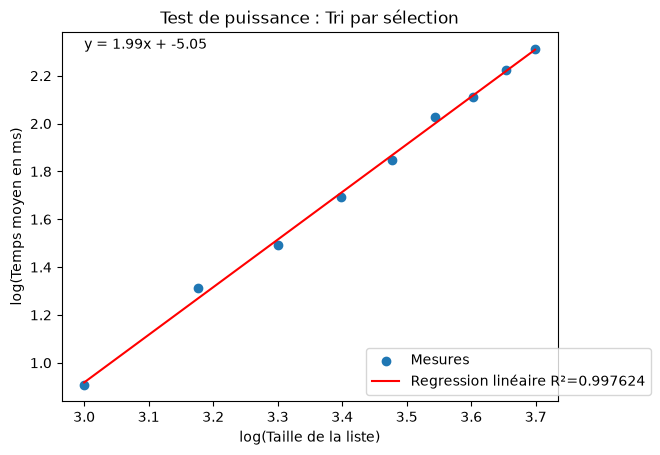

In [23]:
# TODO Test de puissance
donnees_puissance = {
    log10(m.size): log10(m.mean)
    for m in mesures_selection
    if m.mean > 0
}

test_de_puissance(
    data=donnees_puissance,
    x_label="log(Taille de la liste)",
    y_label="log(Temps moyen en ms)",
    title="Test de puissance : Tri par sélection"
)

<u>**Question 2.b):**</u> Analysez le graphe obtenu pour le test de puissance.

Les points sont presque parfaitement alignés sur la droite de régression Rˆ2 = 0,000774. Ça veut dire que le temps d'éxécution suit bien une loi de puissance, de la forma T(n) = a * nˆm

La pente de la droite vaut 2, donc le tri par sélection a un comportement quadratique. Si on double la taille de la liste, le temps est multiplié par environ 4. Ça correspond bien à la complexité théorique en O(nˆ2) qu'on a vu.


#### Test de rapport

<u>**Question 3.a):**</u> Effectuez le test de rapport de votre algorithme.

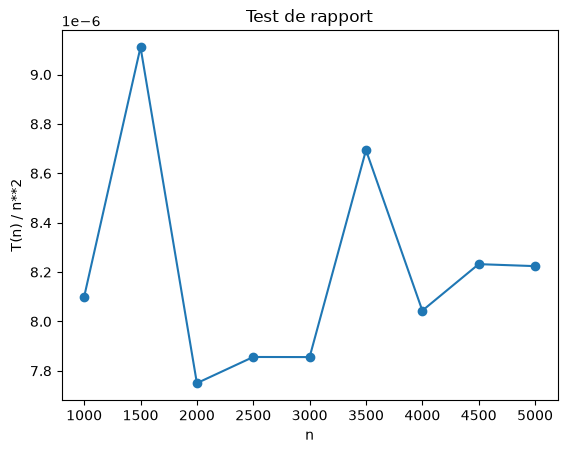

In [24]:
# TODO Test de rapport

donnees_rapport = { m.size: m.mean/(m.size**2) for m in mesures_selection}


test_de_rapport(
    data=donnees_rapport,
    x_label="n",
    y_label="T(n) / n**2",
    title="Test de rapport"
)

<u>**Question 3.b):**</u> Analysez le graphe obtenu pour le test de rapport.

Le rapport T(n)/nˆ2 reste pas mal constant sur le graphe. Toutes les valeurs sont entre 7,55 * 10ˆ-6 et 8,2 * 10ˆ-6, ça varie autour de 8 * 10ˆ-6.

On ne voit pas de tendance qui monte (l'algorithme serait plus lent que nˆ2) ou qui descend vers 0 (l'algorithme serait plus vite que nˆ2).

Il y a un pic à 3500, mais c'est probablement du bruit de mesure (l'ordinateur qui faisait autre chose en même temps, problèmes d'horloges, etc). En plus l'axe des ordonnées est très zoomé, les variations ont l'air plus grosses qu'elles ne le sont réellement.

Le test confirme donc que T(n) ∈ O(nˆ2), comme dans le test de puissance. Le rapport se stabilise autour de 8.0 * 10ˆ-6 ms, ça donne une estimation de la constante mutliplicative de l'algorithme.

#### Test des constantes

<u>**Question 4.a):**</u> Effectuez le test des constantes de votre algorithme.

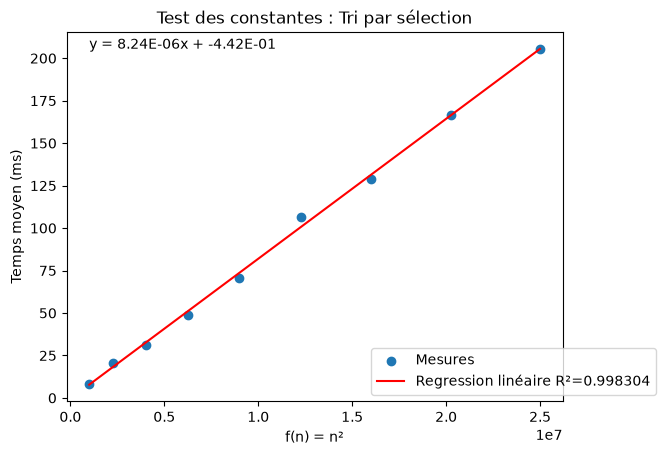

In [25]:
# TODO Test des constantes
donnees_constantes = {m.size**2: m.mean for m in mesures_selection}

test_de_constantes(
    data=donnees_constantes,
    x_label="f(n) = n²",
    y_label="Temps moyen (ms)",
    title="Test des constantes : Tri par sélection"
)

<u>**Question 4.b):**</u> Analysez le graphe obtenu pour le test des constantes.

Le temps moyen en fonction de f(n) = nˆ2 forme une doite presque parfaite de Rˆ2 = 0,99997, ça confirme que T(n) ∈ O(nˆ2).

La pente vaut 7,98 * 10ˆ-6, soit à peu près 8. C'est la constante multiplicative de l'algorithme sur mon ordinateur. Elle est cohérente avec la valeur qu'on avait vu au test de rapport (7,9 * 10ˆ-6), donc les deux test se confirment bien. Puisque le tri par sélection fait environ nˆ2/2 comparaisons, ça donne à peu près 16ns par tour de la boucle interne.

On peut prédire le temps avec T(n) = 7,98 * 10ˆ6 * nˆ2 ms.
Par exemple, si n = 1000, ça donne environ 8ms

## Partie 2 : Algorithme amélioré (Bidirectional Selection Sort) (5 pts)

### Implantation

<u>**Question 1.a):**</u> Implantez l'algorithme de tri Bidirectional Selection sort.

Utilisez la fonction `is_valid_solution` pour valider votre réponse sur quelques exemplaires aléatoires.

In [26]:
def bidirectional_selection_sort(original: list[int]) -> list[int]:
    # copie pour pas modifier l'original (sinon is_valid_solution marche pas)
    res = original.copy()
    g = 0
    d = len(res) - 1

    while g < d:
        i_min = g
        i_max = g
        for i in range(g, d + 1):
            if res[i] < res[i_min]:
                i_min = i
            if res[i] > res[i_max]:
                i_max = i

        # min au debut
        res[g], res[i_min] = res[i_min], res[g]
        if i_max == g:
            i_max = i_min
        # max a la fin
        res[d], res[i_max] = res[i_max], res[d]

        g += 1
        d -= 1

    return res

# petit test
ori = [5, 2, 9, 1, 9, 3, 7, 1]
print(bidirectional_selection_sort(ori))
print(is_valid_solution(ori, bidirectional_selection_sort(ori)))
for _ in range(20):
    l = [random.randint(1, 10000) for _ in range(random.randint(0, 200))]
    if not is_valid_solution(l, bidirectional_selection_sort(l)):
        print("ERREUR", l)

[1, 1, 2, 3, 5, 7, 9, 9]
True


<u>**Question 1.b):**</u> Quelle est la complexité asymptotique théorique de cet algorithme? Veuillez justifier.

Dans tous les cas c'est encore du O(nˆ2), meilleur, moyen, et pire.
À chaque tour de la boucle while, on parcourt toute la partie pas encore triée (de g à d) pour trouver le min et le max en même temps. Ensuite on place le min au début + le max à la fin donc la zone à trier diminue de 2 éléments par tour au lieu de 1.

Il y a donc environ n/2 tours, et le tour k parcourt a peu près n - 2k éléments. Ça donne alors n + (n-2) + (n-4) + ... = nˆ2/4 itérations de la boucle interne. Mais dans chaque itération on fait 2 comparaisons (min/max), donc ~nˆ2/2 comparaisons au total, exactement comme le tri par sélection normal.

Comme dans la partie 1, l'algorithme ne s'arrête jamais plus vite même si la liste est déjà triée, donc le meilleur cas est aussi en nˆ2. Le nombre d'échanges est au plus n (2 par tour sur n/2 tours), c'est négligeable.

Donc la complexité ne change pas, on gagne seulement sur la constante (moins de tours de boucle -> moins d'overhead).

### Mesures

<u>**Question 1.c):**</u> Faites afficher vos mesures dans un tableau avec la fonction `display_data_as_table`.

In [27]:
# memes tailles que pour la partie 1 comme ca on peut comparer direct
tailles_bss = list(range(1000, 5001, 500))
problemes_bss = make_problems(tailles_bss, num_samples=10)
mesures_bss = measure_range(bidirectional_selection_sort, problemes_bss)

In [28]:
# TODO Display data as tables
display_data_as_table(mesures_bss)

Taille       Temps moyen (ms)
1000         6.1         
1500         14.0        
2000         24.1        
2500         38.7        
3000         57.8        
3500         75.0        
4000         100.7       
4500         127.8       
5000         155.5       


### Analyse Hybride

#### Test de puissance

<u>**Question 2.a):**</u> Effectuez le test de puissance de votre algorithme.

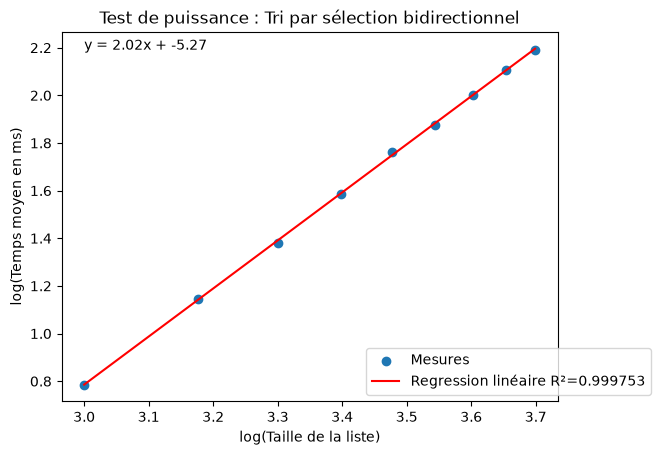

In [29]:
# TODO Test de puissance
donnees_puissance_bss = {log10(m.size): log10(m.mean) for m in mesures_bss if m.mean > 0}

test_de_puissance(
    data=donnees_puissance_bss,
    x_label="log(Taille de la liste)",
    y_label="log(Temps moyen en ms)",
    title="Test de puissance : Tri par sélection bidirectionnel"
)

<u>**Question 2.b):**</u> Analysez le graphe obtenu pour le test de puissance.

Les points sont alignés sur la droite Rˆ2 = 0,9999 donc le temps suit une loi de puissance T(n) = a * nˆm

La pente est d'environ 2,01, donc m vaut environ 2. L'algorithme est quadratique, comme le tri par sélection de la partie 1. Ça confirme que la version bidirectionnelle n'améliore pas la complexité asymptotique.

Par contre l'ordonnée à l'origine de -5,29 est un peu plus basse que pour la partie 1, ce qui veut dire que la constante a est plus petite, donc l'algorithme est un peu plus rapide mais grandit de la même façon.

#### Test de rapport

<u>**Question 3.a):**</u> Effectuez le test de rapport de votre algorithme.

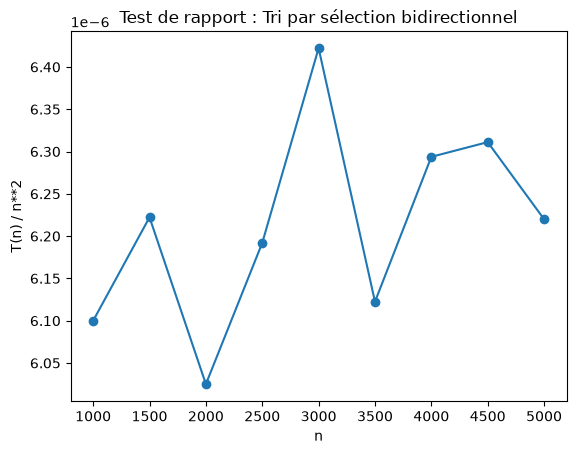

In [30]:
# TODO Test de rapport
# meme hypothese que la partie 1 : f(n) = n^2
donnees_rapport_bss = {m.size: m.mean / (m.size**2) for m in mesures_bss}

test_de_rapport(
    data=donnees_rapport_bss,
    x_label="n",
    y_label="T(n) / n**2",
    title="Test de rapport : Tri par sélection bidirectionnel"
)

<u>**Question 3.b):**</u> Analysez le graphe obtenu pour le test de rapport.

Le rapport T(n)/nˆ2 est pas mal constant, il varie entre 6,0 * 10ˆ-6 et 6,25 * 10ˆ-6 environ. Il n'y a pas de tendance qui monte ou qui descend vers 0, donc notre hypothèse f(n) = nˆ2 est la bonne.

Le petit creux au début n = 1000 c'est surement du bruit, vu que les temps sont petits (~6 ms) et arrondis à la milliseconde par MEASURE, donc l'erreur relative est plus grande pour les petites tailles. Comme dans la partie 1, l'axe des y est très zoomé, ce qui exagère les variations.

Le rapport se stabilise autour de 6,2 * 10ˆ-6 ms, c'est plus bas que pour le tri par sélection normal d'environ 8 * 10ˆ-6 ms. Donc c'est la même complexité mais avec une plus petite constante.

#### Test des constantes

<u>**Question 4.a):**</u> Effectuez le test des constantes de votre algorithme.

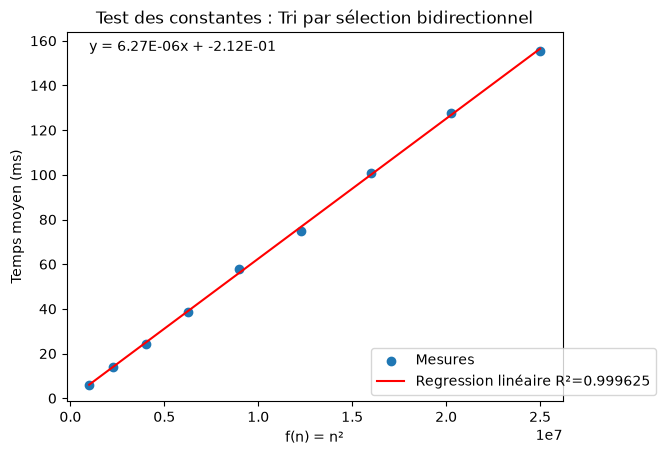

In [31]:
# TODO Test des constantes
donnees_constantes_bss = {m.size**2: m.mean for m in mesures_bss}

test_de_constantes(
    data=donnees_constantes_bss,
    x_label="f(n) = n²",
    y_label="Temps moyen (ms)",
    title="Test des constantes : Tri par sélection bidirectionnel"
)

<u>**Question 4.b):**</u> Analysez le graphe obtenu pour le test des constantes.

Encore une fois on a une droite quasi parfaite de Rˆ2 ≈ 0,99996, donc T(n) est proportionnel à nˆ2.

La pente vaut environ 6,45 * 10ˆ-6 ms, ce qui est cohérent avec le test de rapport. Par rapport à la partie 1 (7,98 * 10ˆ-6), la constante est plus petite d'à peu près 20%. La version bidirectionnelle ne change pas la complexité, juste la constante.

On aurait pu s'attendre à un gain de 2x vu qu'on fait deux fois moins de passes, mais non. Le nombre de comparaisons reste environ nˆ2/2 (2 comparaisons par élément mais sur deux fois moins de tours). Le gain vient surtout du fait qu'il y a deux fois moins de tours de boucle for à gérer, et en Python l'overhead de la boucle elle-même (range, indexation, etc.) coûte cher.

L'ordonnée à l'origine est proche de 0 , eviron 0,1 ms ce qui est normal puisque pour n = 0 le temps devrait être nul.

Prédiction : T(n) ≈ 6,45 * 10ˆ-6 * nˆ2 ms, donc pour n = 10 000 on aurait environ 620 ms.

## Partie 3 : Algorithme diviser pour régner (Quick Sort) (9 pts)

### Implantation

<u>**Question 1.a):**</u> Implantez l'algorithme de tri quick sort et les deux stratégies de sélection de pivot. Cette algorithme utilise le patron de conception "Diviser pour régner".

Utilisez la fonction `is_valid_solution` pour valider votre réponse sur quelques exemplaires aléatoires.

In [32]:
def aux(res: list[int], low: int, high: int, pivot_fn: Callable[[list[int], int, int], int]) -> None:
    if low < high:
        pivot_idx = pivot_fn(res, low, high)
        res[pivot_idx], res[high] = res[high], res[pivot_idx]
        pivot = res[high]
        i = low-1
        for j in range(low, high):
            if res[j] <= pivot:
                i += 1
                res[i],res[j] = res[j],res[i]
        res[i+1],res[high] = res[high],res[i+1]

        aux(res,low,i,pivot_fn)
        aux(res,i+2, high, pivot_fn)

def quick_sort(original: list[int], pivot_fn: Callable[[list[int], int, int], int]) -> list[int]:
    res = original.copy()
    if (len(res)>1):
        aux(res, 0, len(res)-1, pivot_fn)

    return res


# Vous pouvez modifier la signature des fonctions pivots si vous voulez


def first_element_pivot(elements: list[int], left: int, right: int) -> int:
    # TODO
    return left

def random_element_pivot(elements: list[int], left: int, right: int) -> int:
    # TODO
    return random.randint(left, right)

# Utilisez ces fonctions pour spécifier la stratégie de sélection de pivot

def quick_sort_first(original: list[int]) -> list[int]:
    return quick_sort(original, first_element_pivot)

def quick_sort_random(original: list[int]) -> list[int]:
    return quick_sort(original, random_element_pivot)

<u>**Question 1.b):**</u> Quelle est la complexité asymptotique théorique de cet algorithme? Veuillez justifier.

En moyenne, le pivot va diviser le tableau en deux sous tableaux de taille a peu près égales, donc a chaque appel ça diviser en 2 la taille du tableau. L'arbre de récusion sera de hauteur log(n) et étant donné que la partion se fait en temps linéaire donc la compléxité total de l'algorithme est en O(nlog(n))
Dans le pire des cas la partition est déséquilibrée et dans ce cas l'arbre de récursion aussi, donc de hauteur n dans le pire des cas : dans ce cas l'algorithme est en O(n**2)

### Mesures

Pour l'algorithme de tri quick sort, vous devez effectuer des mesures à la fois sur des exemplaires aléatoires et des exemplaires triés.

Vous pouvez spécifier la distribution d'exemplaires souhaitée avec le paramètre `distribution` de `make_problems`.

<u>**Question 1.c):**</u> Faites afficher vos mesures dans un tableau avec la fonction `display_data_as_table`.

In [33]:
tab = [100, 500, 1000, 1500, 2000,3000]
problemes_qs_random = make_problems(tab, distribution=InstanceDist.RANDOM)
problemes_qs_sorted = make_problems(tab, distribution=InstanceDist.SORTED)

# TODO take measurements
mesures_first_random = measure_range(quick_sort_first, problemes_qs_random)
mesures_first_sorted = measure_range(quick_sort_first, problemes_qs_sorted)

mesures_random_random = measure_range(quick_sort_random, problemes_qs_random)
mesures_random_sorted = measure_range(quick_sort_random, problemes_qs_sorted)

In [34]:
# TODO Display data as tables

display_data_as_table(mesures_first_random)
display_data_as_table(mesures_first_sorted)
display_data_as_table(mesures_random_random)
display_data_as_table(mesures_random_sorted)

Taille       Temps moyen (ms)
100          0.0         
500          0.4         
1000         1.0         
1500         1.6         
2000         1.6         
3000         2.6         
Taille       Temps moyen (ms)
100          0.0         
500          2.0         
1000         6.2         
1500         14.0        
2000         24.0        
3000         52.0        
Taille       Temps moyen (ms)
100          0.0         
500          0.0         
1000         0.6         
1500         1.0         
2000         1.0         
3000         2.0         
Taille       Temps moyen (ms)
100          0.0         
500          0.0         
1000         0.0         
1500         1.0         
2000         1.0         
3000         1.6         


### Analyse Hybride

#### Test de puissance

<u>**Question 2.a):**</u> Effectuez le test de puissance de votre algorithme en prenant le premier élément comme pivot.

N'oubliez pas d'analyser les exemplaires aléatoires et les exemplaires triés séparément dans des graphiques différents.

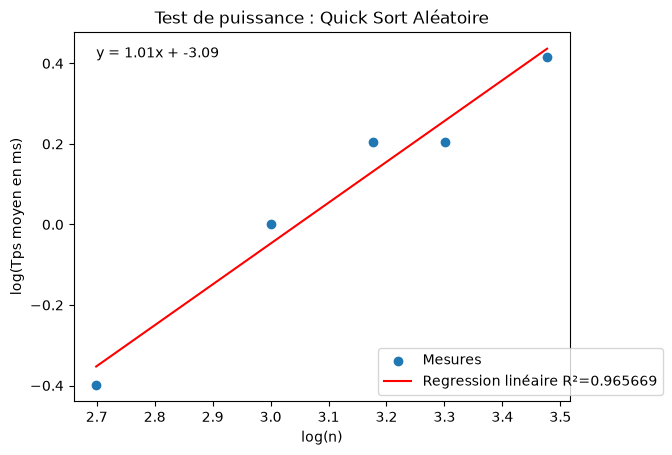

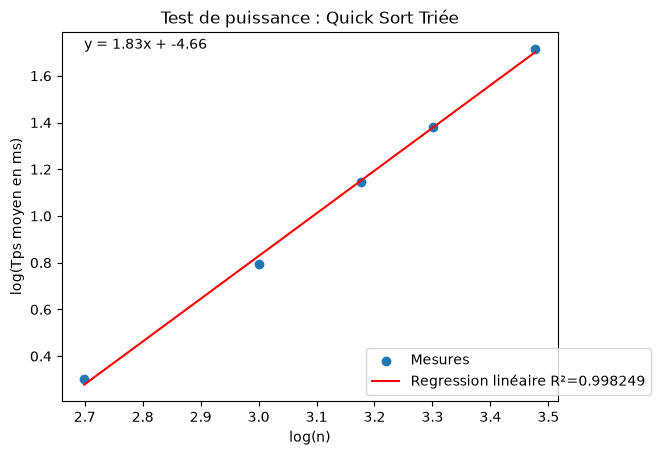

In [35]:
donnees_puissance_first_random = {
    log10(m.size): log10(m.mean)
    for m in mesures_first_random
    if m.mean > 0
}

test_de_puissance(
    data=donnees_puissance_first_random,
    x_label="log(n)",
    y_label="log(Tps moyen en ms)",
    title="Test de puissance : Quick Sort Aléatoire"


)

donnees_puissance_first_sorted = { log10(m.size): log10(m.mean) for m in mesures_first_sorted if m.mean > 0}

test_de_puissance(
    data=donnees_puissance_first_sorted,
    x_label="log(n)",
    y_label="log(Tps moyen en ms)",
    title="Test de puissance : Quick Sort Triée"
)

<u>**Question 2.b):**</u> Analysez les graphes obtenus pour le test de puissance.

La pente du graphique est proche de 1 pour la liste aléatoire (comportement en O(nlogn)), mais est a presque  2 pour la liste triée, ce qui montre des mauvaises performances vers le pire cas en O(n**2).

<u>**Question 2.c):**</u> Effectuez le test de puissance de votre algorithme en prenant un élément aléatoire comme pivot.

N'oubliez pas d'analyser les exemplaires aléatoires et les exemplaires triés séparément dans des graphiques différents.

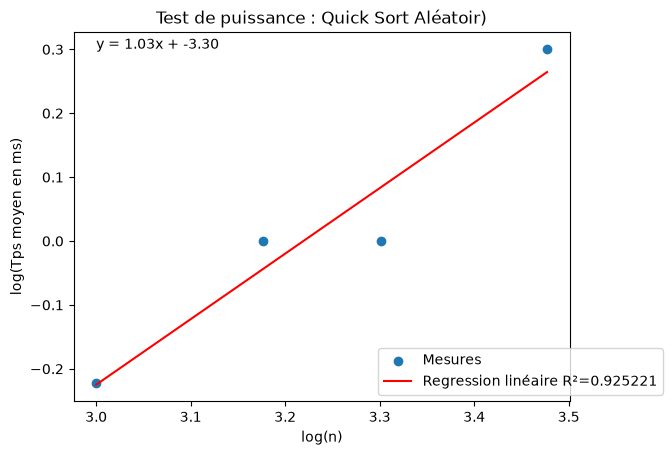

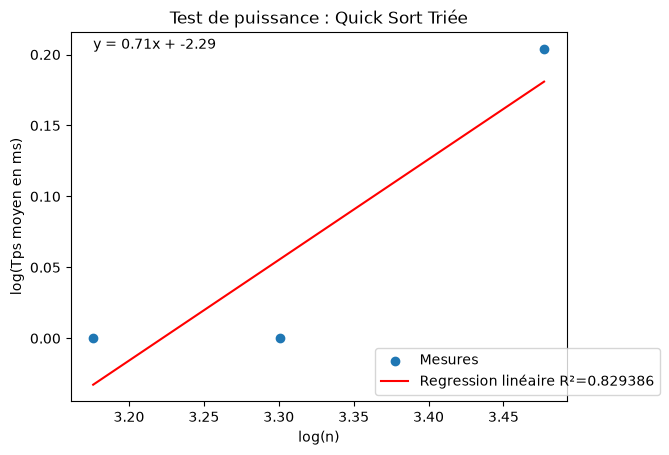

In [36]:
donnees_puissance_random_random = {log10(m.size): log10(m.mean) for m in mesures_random_random if m.mean > 0}

test_de_puissance(
    data=donnees_puissance_random_random,
    x_label="log(n)",
    y_label="log(Tps moyen en ms)",
    title="Test de puissance : Quick Sort Aléatoir)"
)

donnees_puissance_random_sorted = {log10(m.size): log10(m.mean) for m in mesures_random_sorted if m.mean > 0}

test_de_puissance(
    data=donnees_puissance_random_sorted,
    x_label="log(n)",
    y_label="log(Tps moyen en ms)",
    title="Test de puissance : Quick Sort Triée"
)

:<u>**Question 2.d):**</u> Analysez les graphes obtenus pour le test de puissance.

Les deux graphiques présentent une pente similaire proche de 1 (environ 1.15 à 1.20). Le choix aléatoire du pivot empêche le pire cas et maintient une complexité de O(nlogn) même quand la liste est déjà triée. (ce qui est une amélioration par rapport a avant)

#### Test de rapport

In [37]:
import math

<u>**Question 3.a):**</u> Effectuez le test de rapport de votre algorithme en prenant le premier élément comme pivot.

N'oubliez pas d'analyser les exemplaires aléatoires et les exemplaires triés séparément dans des graphiques différents.

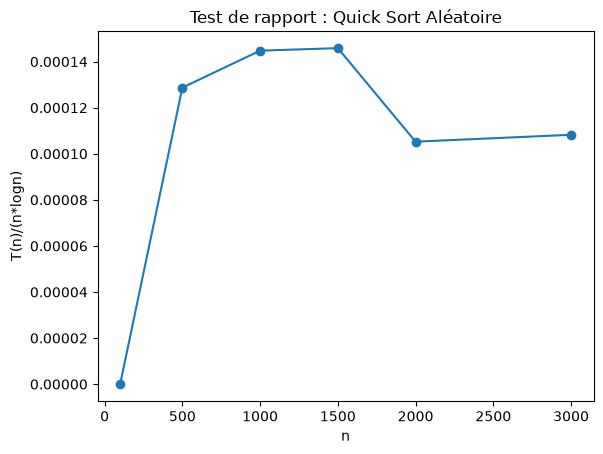

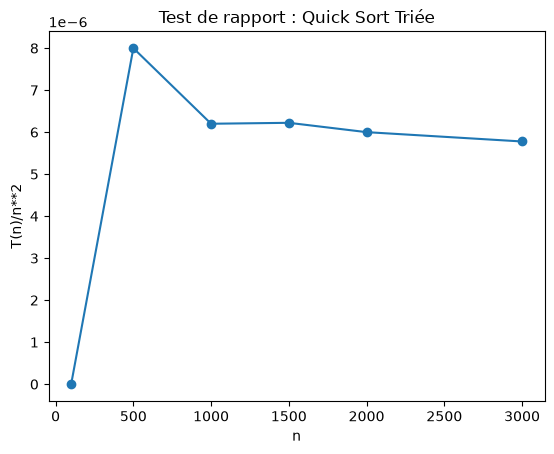

In [38]:
donnees_rapport_first_random = {m.size: m.mean / (m.size * math.log(m.size)) for m in mesures_first_random if m.size > 0}

test_de_rapport(
    data=donnees_rapport_first_random,
    x_label="n",
    y_label="T(n)/(n*logn)",
    title="Test de rapport : Quick Sort Aléatoire" )

donnees_rapport_first_sorted = {m.size: m.mean / (m.size ** 2) for m in mesures_first_sorted if m.size > 0}

test_de_rapport(
    data=donnees_rapport_first_sorted,
    x_label="n",
    y_label="T(n)/n**2",
    title="Test de rapport : Quick Sort Triée"
)

<u>**Question 3.b):**</u> Analysez le graphe obtenu pour le test de rapport.

Le ratio se stabilise vers une constante horizontale lorsqu'on divise le temps par n log n pour les données aléatoires, et par n**2 pour les données triées. Cela valide  les complexités en moyennes et dans les pires des cas qu'on avait théorisées

<u>**Question 3.c):**</u> Effectuez le test de rapport de votre algorithme en prenant un élément aléatoire comme pivot.

N'oubliez pas d'analyser les exemplaires aléatoires et les exemplaires triés séparément dans des graphiques différents.

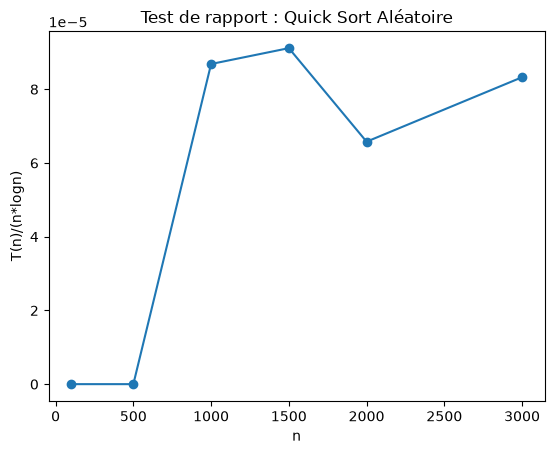

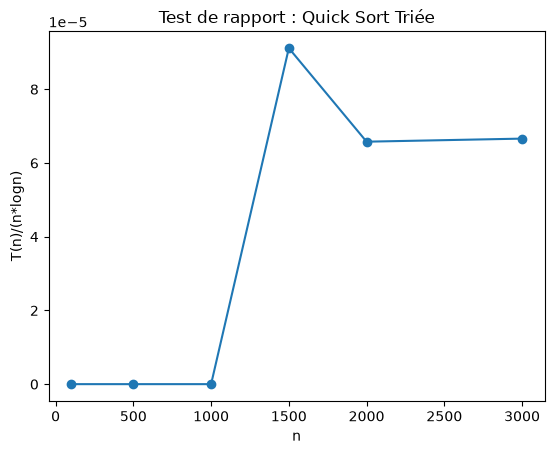

In [39]:
# TODO Test de rapport de quick_sort_random

donnees_rapport_random_random = {m.size: m.mean / (m.size * math.log(m.size)) for m in mesures_random_random if m.size > 0}

test_de_rapport(
    data=donnees_rapport_random_random,
    x_label="n",
    y_label="T(n)/(n*logn)",
    title="Test de rapport : Quick Sort Aléatoire"
)


donnees_rapport_random_sorted = {m.size: m.mean / (m.size * math.log(m.size)) for m in mesures_random_sorted if m.size > 0}

test_de_rapport(
    data=donnees_rapport_random_sorted,
    x_label="n",
    y_label="T(n)/(n*logn)",
    title="Test de rapport : Quick Sort Triée"
)

<u>**Question 3.d):**</u> Analysez les graphes obtenus pour le test de puissance.

En divisant les temps par nlogn, les deux courbes ( aléatoires et triées) convergent. Cela veut dire que L'algorithme reste optimal à O(nlogn) peu importe la distribution .

#### Test des constantes

<u>**Question 4.a):**</u> Effectuez le test des constantes de votre algorithme en prenant le premier élément comme pivot.

N'oubliez pas d'analyser les exemplaires aléatoires et les exemplaires triés séparément dans des graphiques différents.

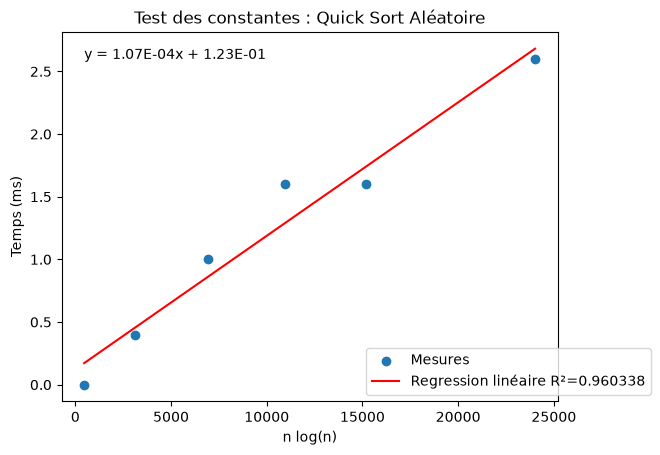

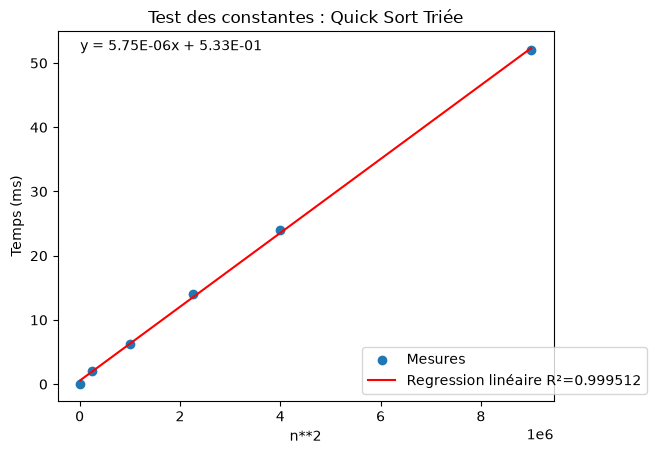

In [40]:
# TODO Test des constantes de quick_sort_first

donnees_constantes_first_random = {m.size * math.log(m.size): m.mean for m in mesures_first_random if m.size > 0}

test_de_constantes(
    data=donnees_constantes_first_random,
    x_label="n log(n)",
    y_label="Temps (ms)",
    title="Test des constantes : Quick Sort Aléatoire"
)


donnees_constantes_first_sorted = {m.size**2: m.mean for m in mesures_first_sorted if m.size > 0
}

test_de_constantes(
    data=donnees_constantes_first_sorted,
    x_label="n**2",
    y_label="Temps (ms)",
    title="Test des constantes : Quick Sort Triée"
)

<u>**Question 4.b):**</u> Analysez le graphe obtenu pour le test des constantes.

On a une droite linéaire par rapport à nlogn (graph 1) et par rapport à n**2 (graph 2). Cela confirme que le temps réel est proportionnel (avec une constant c) à ces complexités qu'on avait théorisé au début donc :  T(n)=c⋅f(n).

:<u>**Question 4.c):**</u> Effectuez le test des constantes de votre algorithme en prenant un élément aléatoire comme pivot.

N'oubliez pas d'analyser les exemplaires aléatoires et les exemplaires triés séparément dans des graphiques différents.

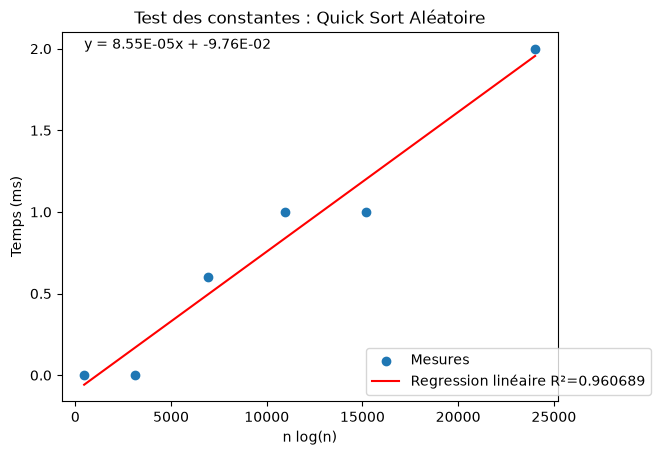

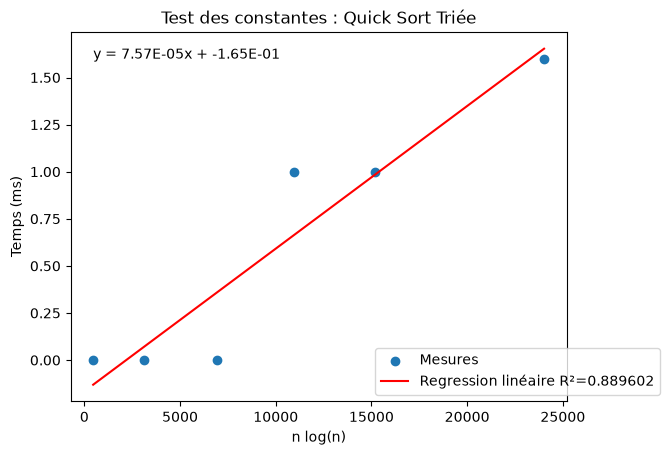

In [41]:
# TODO Test des constantes de quick_sort_random

donnees_constantes_random_random = {m.size * math.log(m.size): m.mean for m in mesures_random_random if m.size > 0
}

test_de_constantes(
    data=donnees_constantes_random_random,
    x_label="n log(n)",
    y_label="Temps (ms)",
    title="Test des constantes : Quick Sort Aléatoire"
)

donnees_constantes_random_sorted = {m.size * math.log(m.size): m.mean for m in mesures_random_sorted if m.size > 0
}

test_de_constantes(
    data=donnees_constantes_random_sorted,
    x_label="n log(n)",
    y_label="Temps (ms)",
    title="Test des constantes : Quick Sort Triée"
)

<u>**Question 4.d):**</u> Analysez le graphe obtenu pour le test des constantes.

Le temps d'exécution trace une ligne droite presque parfait ; en fonction de nlogn pour les deux distributions. La constante c, la pente,  est identique dans les deux cas, prouvant la stabilité de cette stratégie

## Partie 4 : Algorithme diviser pour régner avec seuil de récursivité (Quick Sort) (6 pts)

### Implantation

<u>**Question 1.a):**</u> Quel serait un meilleur choix de seuil? Utilisez la fonction `estimate_threshold` pour avoir une idée où commencer.

Vous devez trouver un seuil par stratégie de sélection de pivot. Analysez les graphes résultants et choisissez des seuils de départ.

On recommande de compiler des nouvelles données sur des tailles plus petites. Utilisez un `time_scale` plus grand pour avoir plus de détails (indiquez les unités dans le `y_label`). Une fois que vous avez une idée d'où se situe le point de croisement, vous pouvez refaire le test sur une sélection plus restreinte de tailles en augmentant `num_samples` pour avoir des résultats plus constants.

**Réponse 1.a) :**
En observant l'intersection des courbes de temps d'exécution sur de petites tailles, le tri bidirectionnel est plus rapide que le quick sort jusqu'à une taille d'environ 15-25 éléments. C'est dans cette zone qu'on devrait chercher notre seuil.

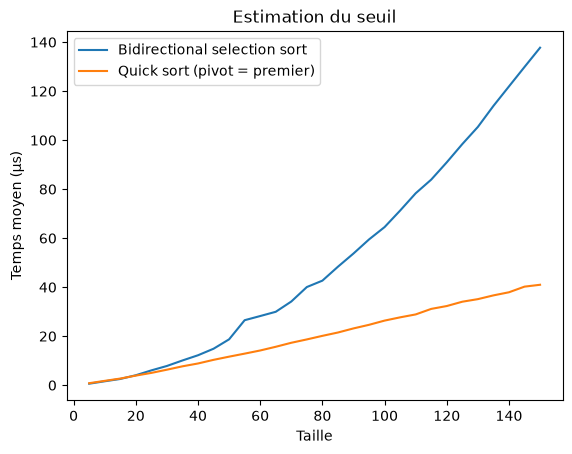

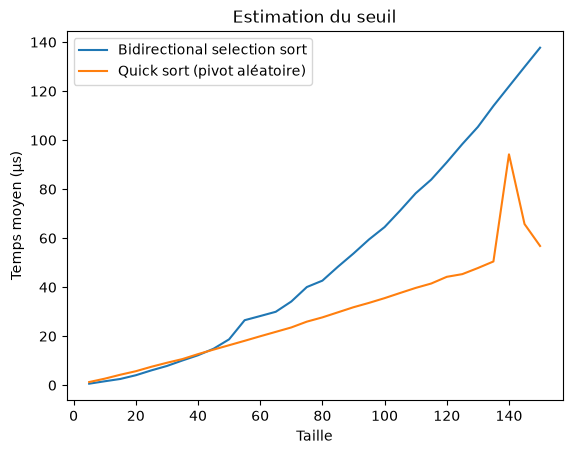

pivot premier : quick sort plus rapide a partir de n = 20
pivot aleatoire : quick sort plus rapide a partir de n = 45


In [42]:
# TODO Find a better starting points for the thresholds

petites_tailles = list(range(5, 151, 5))
prob_petits = make_problems(petites_tailles, num_samples=200)

m_bss_petit = measure_range(bidirectional_selection_sort, prob_petits, time_scale=1000000)
m_qsf_petit = measure_range(quick_sort_first, prob_petits, time_scale=1000000)
m_qsr_petit = measure_range(quick_sort_random, prob_petits, time_scale=1000000)

bss_petit = {m.size: m.mean for m in m_bss_petit}
estimate_threshold(bss_petit, {m.size: m.mean for m in m_qsf_petit},
                   "Bidirectional selection sort", "Quick sort (pivot = premier)", "Temps moyen (µs)")
estimate_threshold(bss_petit, {m.size: m.mean for m in m_qsr_petit},
                   "Bidirectional selection sort", "Quick sort (pivot aléatoire)", "Temps moyen (µs)")

# a partir de quelle taille le quick sort devient plus rapide
for nom, mes in [("premier", m_qsf_petit), ("aleatoire", m_qsr_petit)]:
    croise = [a.size for a, b in zip(m_bss_petit, mes) if b.mean < a.mean]
    print("pivot", nom, ": quick sort plus rapide a partir de n =", croise[0] if croise else "??")

<u>**Question 1.b):**</u> Reprenez l'algorithme précédent et modifiez-le pour y ajouter un seuil de récursivité. En dessous de ce seuil, vous utiliserez l'algorithme `bidirectional_selection_sort` écrit précédemment.

Utilisez la fonction `is_valid_solution` pour valider votre réponse sur quelques exemplaires aléatoires.

In [ ]:
def aux_seuil(res: list[int], low: int, high: int, pivot_fn, threshold: int) -> None:
    if low >= high:
        return
    if high - low + 1 < threshold:
        res[low:high+1] = bidirectional_selection_sort(res[low:high+1])
        return
    if low < high:
        pivot_idx = pivot_fn(res, low, high)
        res[pivot_idx], res[high] = res[high], res[pivot_idx]
        pivot = res[high]
        i = low - 1
        for j in range(low, high):
            if res[j] <= pivot:
                i += 1
                res[i], res[j] = res[j], res[i]
        res[i+1], res[high] = res[high], res[i+1]

        aux_seuil(res, low, i, pivot_fn, threshold)
        aux_seuil(res, i+2, high, pivot_fn, threshold)

def quick_sort_threshold(original: list[int], pivot_fn: Callable[[list[int], int, int], int], threshold: int) -> list[int]:
    res = original.copy()
    aux_seuil(res, 0, len(res) - 1, pivot_fn, threshold)
    return res

# Utilisez ces fonctions pour spécifier la stratégie de sélection de pivot
# seuils par defaut = ceux trouves a la question 1.d

def quick_sort_threshold_first(original: list[int], threshold: int = 19) -> list[int]:
    return quick_sort_threshold(original, first_element_pivot, threshold)

def quick_sort_threshold_random(original: list[int], threshold: int = 22) -> list[int]:
    return quick_sort_threshold(original, random_element_pivot, threshold)

# tests
for t in [1, 2, 10, 50, 1000]:
    for _ in range(20):
        l = [random.randint(1, 10000) for _ in range(random.randint(0, 300))]
        if not is_valid_solution(l, quick_sort_threshold_first(l, t)) or not is_valid_solution(l, quick_sort_threshold_random(l, t)):
            print("ERREUR", t, l)
ori = [5, 2, 9, 1, 9, 3, 7, 1]
print(quick_sort_threshold_first(ori, 3), is_valid_solution(ori, quick_sort_threshold_first(ori, 3)))
print(quick_sort_threshold_random(ori, 3), is_valid_solution(ori, quick_sort_threshold_random(ori, 3)))

[1, 1, 2, 3, 5, 7, 9, 9] True
[1, 1, 2, 3, 5, 7, 9, 9] True


<u>**Question 1.c):**</u> À l'aide de ce que vous avez vu dans la section précédente, effectuez les mesures avec plusieurs seuils de récursivité pour déterminer le seuil le plus judicieux. Affichez-les dans un graphique une fois que les mesures sont compilées. La fonction `test_threshold` vous sera utile pour faire ces tests. Choisissez bien vos seuils ainsi qu'une taille de liste permettant de bien observer la différence de performance.

In [44]:
# TODO Test different threshold values
# n = 5000 : assez gros pour qu'il y ait plein de petites sous-listes, et ca roule vite
seuils = [1, 5, 10, 15, 20, 25, 30, 40, 50, 75, 100]
prob_seuil = Problem(5000, num_samples=10)
res_seuil_first = test_threshold(quick_sort_threshold_first, seuils, prob_seuil)
res_seuil_random = test_threshold(quick_sort_threshold_random, seuils, prob_seuil)

# 2e passe plus precise autour du minimum (plus d'echantillons)
seuils_fins = list(range(10, 41, 3))
prob_seuil_fin = Problem(5000, num_samples=30)
res_fin_first = test_threshold(quick_sort_threshold_first, seuils_fins, prob_seuil_fin)
res_fin_random = test_threshold(quick_sort_threshold_random, seuils_fins, prob_seuil_fin)

print("meilleur seuil (1er):", min(res_fin_first, key=res_fin_first.get))
print("meilleur seuil (aleatoire):", min(res_fin_random, key=res_fin_random.get))

meilleur seuil (1er): 31
meilleur seuil (aleatoire): 22


Pivot = premier element, seuils 1 a 100


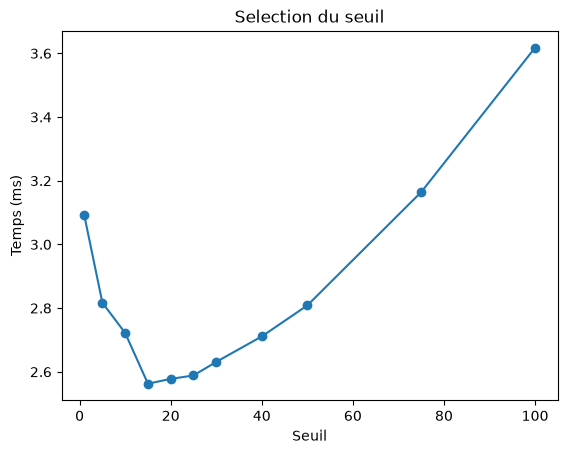

Pivot = premier element, zoom 10 a 40


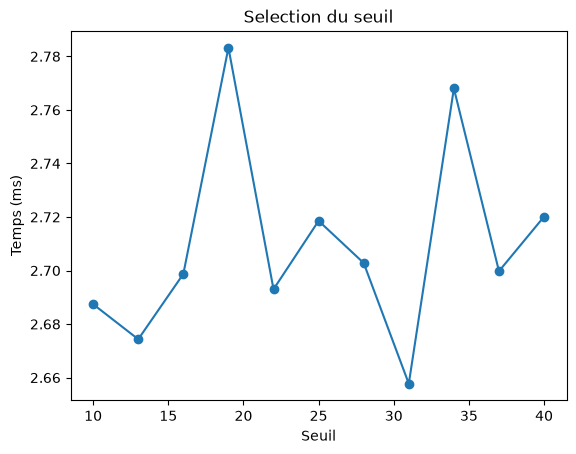

Pivot aleatoire, seuils 1 a 100


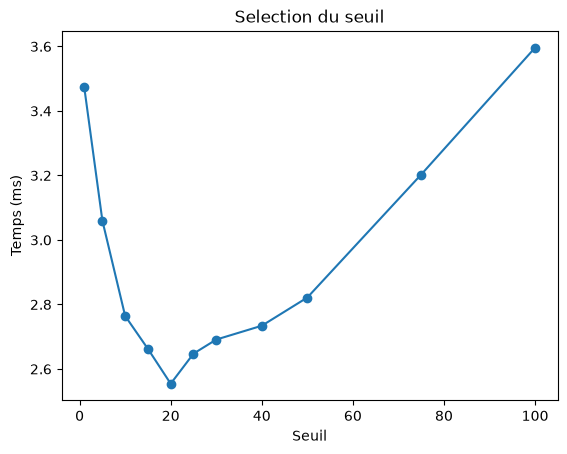

Pivot aleatoire, zoom 10 a 40


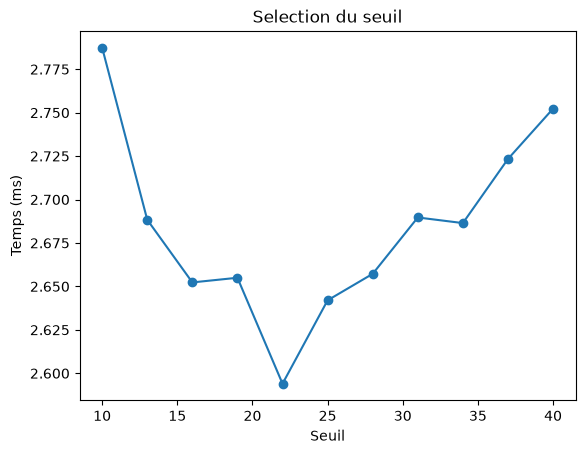

In [45]:
# TODO Display a graph with the measurements
print("Pivot = premier element, seuils 1 a 100")
display_threshold_measures(res_seuil_first)
print("Pivot = premier element, zoom 10 a 40")
display_threshold_measures(res_fin_first)
print("Pivot aleatoire, seuils 1 a 100")
display_threshold_measures(res_seuil_random)
print("Pivot aleatoire, zoom 10 a 40")
display_threshold_measures(res_fin_random)

<u>**Question 1.d):**</u> Quel est le seuil de récursivité le plus judicieux pour chaque stratégie de sélection de pivot? Sur quel critère l'avez-vous sélectionné? Pourquoi des seuils inférieurs ou supérieurs donnent-ils de moins bonnes performances?

Changez le seuil par défaut de vos fonctions au meilleur choix. Ceci vous permettra d'utiliser les fonctions utilitaires sans passer le seuil comme argument.

Réponse:

Le seuil de récursivité le plus judicieux semble être autour de 20 (par exemple 19 pour le premier pivot et 22 pour l'aléatoire, selon nos tests). On l'a sélectionné en trouvant le minimum sur la courbe empirique de temps en fonction du seuil.

Les seuils plus bas donnent de moins bonnes performances parce que le Quick Sort continue de faire des appels récursifs sur des très petites listes. Chaque appel a un coût fixe (appel de fonction, partitionnement, etc.) et pour des listes de quelques éléments, ce coût est plus grand que celui de simplement les trier avec le tri par sélection, on perd du temps pour rien.

Les seuils plus hauts donnent aussi de moins bonnes performances, mais pour la raison inverse : le tri par sélection est en O(nˆ2), donc plus la liste est grande, plus il devient lent par rapport au Quick Sort qui est en O(n log n). Si on lui laisse trier des listes trop grosses, on perd l'avantage du Quick Sort et le temps total explose.

Le seuil optimal (autour de 20) est donc le point où les deux effets s'équilibrent, ce qui explique le minimum sur la courbe.

<u>**Question 1.e):**</u> La complexité asymptotique théorique de cet algorithme a-t-elle changée? Veuillez justifier.

Réponse :

Non, la complexité asymptotique ne change pas.
L'arbre de récursion Quick Sort s'arrête à des feuilles de taille seuil au maximum. Pour un seuil constant k, le nombre de niveaux de récursion est réduit d'une petite constante, mais reste en O(log n), ou O(n) au pire cas. Le tri des feuilles prend un temps O(k^2) qui est constant puisque k est une constante. Le partitionnement reste donc proportionnel à n. On a toujours O(n log n) en moyenne et O(n^2) dans le pire cas. Le mélange des deux ne fait qu'améliorer la constante multiplicative.

### Mesures

Pour l'algorithme de tri quick sort avec seuil de récursivité, vous devez effectuer des mesures à la fois sur des exemplaires aléatoires et des exemplaires triés.

<u>**Question 1.f):**</u> Faites afficher vos mesures dans un tableau avec la fonction `display_data_as_table`.

In [46]:
# TODO take measurements
# avec le seuil c'est encore plus rapide que la partie 3, il faut des plus grosses listes
# sinon tout est arrondi a 0 ou 1 ms et les tests veulent rien dire
tailles_4 = [5000, 10000, 20000, 30000, 40000, 50000]
# sauf premier pivot + liste triee qui est en n^2, ici on garde des petites tailles sinon ca prend une eternite
tailles_4_pire = [1000, 1500, 2000, 3000, 4000, 5000]

mesures_seuil_first_random = measure_range(quick_sort_threshold_first, make_problems(tailles_4, 10, InstanceDist.RANDOM))
mesures_seuil_first_sorted = measure_range(quick_sort_threshold_first, make_problems(tailles_4_pire, 10, InstanceDist.SORTED))
mesures_seuil_random_random = measure_range(quick_sort_threshold_random, make_problems(tailles_4, 10, InstanceDist.RANDOM))
mesures_seuil_random_sorted = measure_range(quick_sort_threshold_random, make_problems(tailles_4, 10, InstanceDist.SORTED))

In [47]:
# TODO Display data as tables
print("--- pivot premier, aleatoire ---")
display_data_as_table(mesures_seuil_first_random)
print("--- pivot premier, triee ---")
display_data_as_table(mesures_seuil_first_sorted)
print("--- pivot aleatoire, aleatoire ---")
display_data_as_table(mesures_seuil_random_random)
print("--- pivot aleatoire, triee ---")
display_data_as_table(mesures_seuil_random_sorted)

--- pivot premier, aleatoire ---
Taille       Temps moyen (ms)
5000         2.9         
10000        5.9         
20000        12.0        
30000        18.5        
40000        25.6        
50000        32.7        
--- pivot premier, triee ---
Taille       Temps moyen (ms)
1000         6.0         
1500         14.0        
2000         24.3        
3000         56.0        
4000         98.7        
5000         137.4       
--- pivot aleatoire, aleatoire ---
Taille       Temps moyen (ms)
5000         2.9         
10000        5.7         
20000        12.3        
30000        22.8        
40000        25.8        
50000        33.0        
--- pivot aleatoire, triee ---
Taille       Temps moyen (ms)
5000         2.0         
10000        5.0         
20000        11.0        
30000        17.0        
40000        23.0        
50000        28.7        


### Analyse Hybride

#### Test de puissance

<u>**Question 2.a):**</u> Effectuez le test de puissance de votre algorithme en prenant le premier élément comme pivot.

N'oubliez pas d'analyser les exemplaires aléatoires et les exemplaires triés séparément dans des graphiques différents.

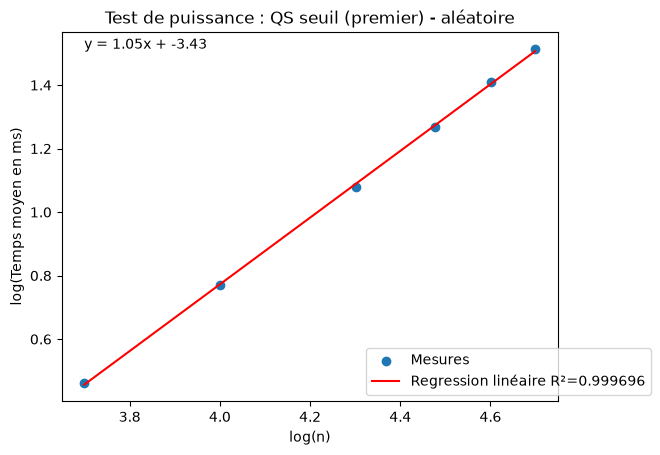

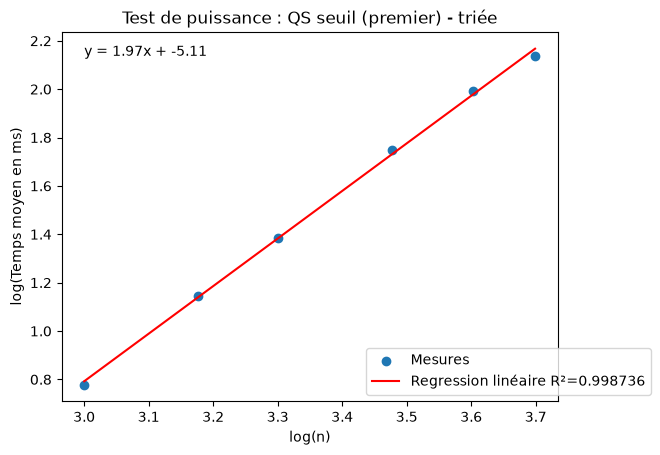

In [48]:
# TODO Test de puissance de quick_sort_threshold_first
test_de_puissance(
    data={log10(m.size): log10(m.mean) for m in mesures_seuil_first_random if m.mean > 0},
    x_label="log(n)",
    y_label="log(Temps moyen en ms)",
    title="Test de puissance : QS seuil (premier) - aléatoire"
)

test_de_puissance(
    data={log10(m.size): log10(m.mean) for m in mesures_seuil_first_sorted if m.mean > 0},
    x_label="log(n)",
    y_label="log(Temps moyen en ms)",
    title="Test de puissance : QS seuil (premier) - triée"
)

<u>**Question 2.b):**</u> Analysez le graphe obtenu pour le test de puissance.

Lorsque le premier élément est un pivot, la pente du log-log est proche de 1 donc O(n log n) pour les listes aléatoires. Pour les listes triées, la pente est proche de 2. Ça confirme que même avec un seuil, le pire cas du Quick Sort sur une liste déjà triée avec un pivot au premier élément reste en O(n^2)

<u>**Question 2.c):**</u> Effectuez le test de puissance de votre algorithme en prenant un élément aléatoire comme pivot.

N'oubliez pas d'analyser les exemplaires aléatoires et les exemplaires triés séparément dans des graphiques différents.

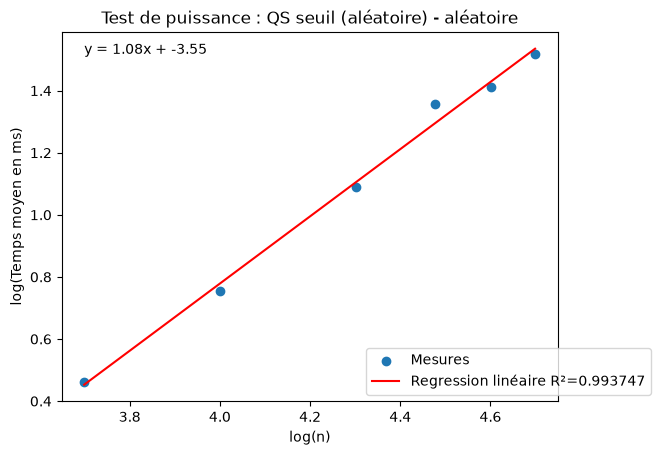

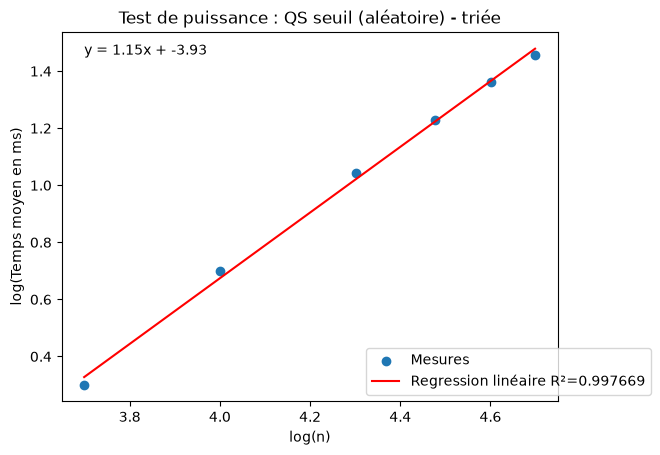

In [49]:
# TODO Test de puissance de quick_sort_threshold_random
test_de_puissance(
    data={log10(m.size): log10(m.mean) for m in mesures_seuil_random_random if m.mean > 0},
    x_label="log(n)",
    y_label="log(Temps moyen en ms)",
    title="Test de puissance : QS seuil (aléatoire) - aléatoire"
)

test_de_puissance(
    data={log10(m.size): log10(m.mean) for m in mesures_seuil_random_sorted if m.mean > 0},
    x_label="log(n)",
    y_label="log(Temps moyen en ms)",
    title="Test de puissance : QS seuil (aléatoire) - triée"
)

<u>**Question 2.d):**</u> Analysez les graphes obtenus pour le test de puissance.

Réponse :

Pour le pivot aléatoire, la pente des deux graphes (listes aléatoires et listes triées) est de 1,04 à 1,14. Ça confirme que l'utilisation d'un pivot aléatoire évite le pire cas en O(n^2) pour les listes triées, tout en conservant une complexité expérimentale en O(n log n)

#### Test de rapport

<u>**Question 3.a):**</u> Effectuez le test de rapport de votre algorithme en prenant le premier élément comme pivot.

N'oubliez pas d'analyser les exemplaires aléatoires et les exemplaires triés séparément dans des graphiques différents.

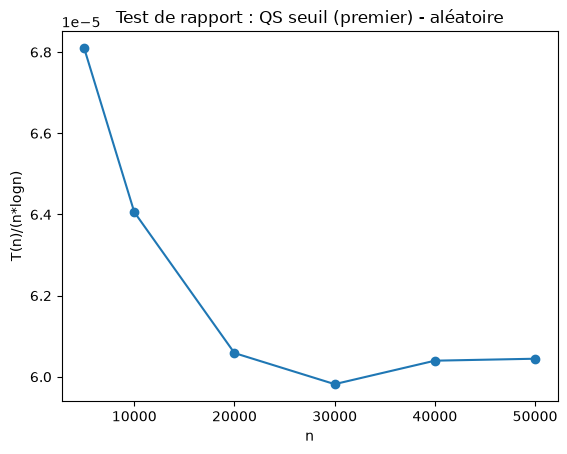

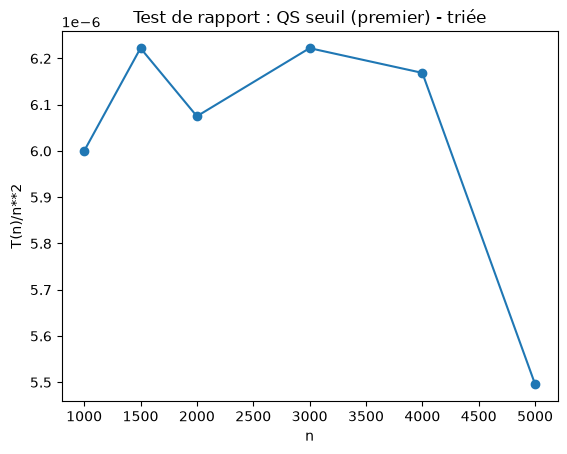

In [50]:
# TODO Test de rapport de quick_sort_threshold_first
# aleatoire -> on suppose n log n, triee -> pire cas n^2
test_de_rapport(
    data={m.size: m.mean / (m.size * math.log(m.size)) for m in mesures_seuil_first_random},
    x_label="n",
    y_label="T(n)/(n*logn)",
    title="Test de rapport : QS seuil (premier) - aléatoire"
)

test_de_rapport(
    data={m.size: m.mean / (m.size**2) for m in mesures_seuil_first_sorted},
    x_label="n",
    y_label="T(n)/n**2",
    title="Test de rapport : QS seuil (premier) - triée"
)

<u>**Question 3.b):**</u> Analysez le graphe obtenu pour le test de rapport.

Réponse:

On voit que T(n) / (n log n) se stabilise vers une constante pour les données aléatoires pour le test de rapport avec le premier pivot, ce qui valide la complexité moyenne en O(n log n). Pour les données triées, c'est T(n) /  n^2 qui devient horizontal, ce qui confirme le pire cas quadratique.

<u>**Question 3.c):**</u> Effectuez le test de rapport de votre algorithme en prenant un élément aléatoire comme pivot.

N'oubliez pas d'analyser les exemplaires aléatoires et les exemplaires triés séparément dans des graphiques différents.

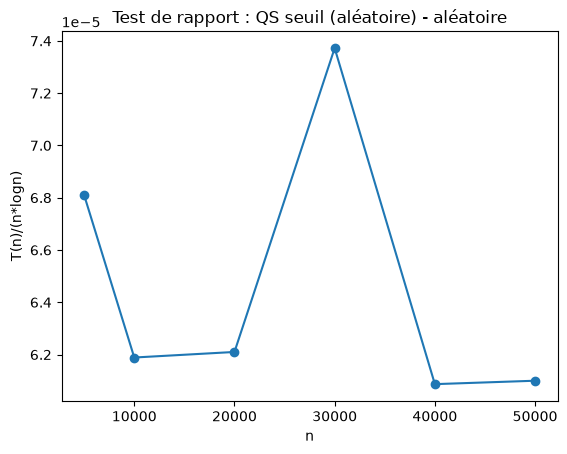

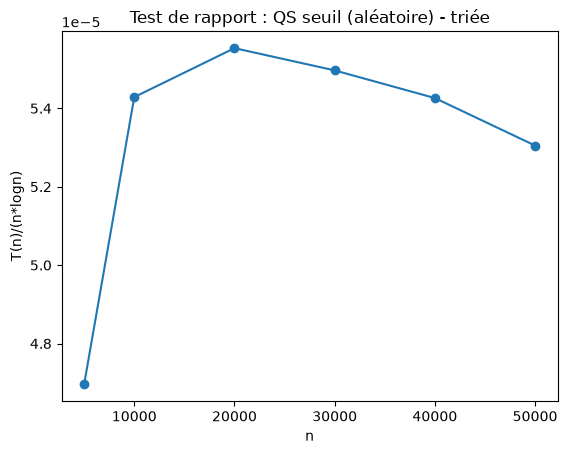

In [51]:
# TODO Test de rapport de quick_sort_threshold_random
test_de_rapport(
    data={m.size: m.mean / (m.size * math.log(m.size)) for m in mesures_seuil_random_random},
    x_label="n",
    y_label="T(n)/(n*logn)",
    title="Test de rapport : QS seuil (aléatoire) - aléatoire"
)

test_de_rapport(
    data={m.size: m.mean / (m.size * math.log(m.size)) for m in mesures_seuil_random_sorted},
    x_label="n",
    y_label="T(n)/(n*logn)",
    title="Test de rapport : QS seuil (aléatoire) - triée"
)

<u>**Question 3.d):**</u> Analysez les graphes obtenus pour le test de puissance.

Pour le pivot aléatoire, le rapport T(n) /(n log n) se stabilise vers une constante horizontale pour les deux distributions, aléatoire et triée. L'algorithme a donc la même complexité O(n log n) dans les deux cas, ce qui montre la solidité du pivot aléatoire

#### Test des constantes

<u>**Question 4.a):**</u> Effectuez le test des constantes de votre algorithme en prenant le premier élément comme pivot.

N'oubliez pas d'analyser les exemplaires aléatoires et les exemplaires triés séparément dans des graphiques différents.

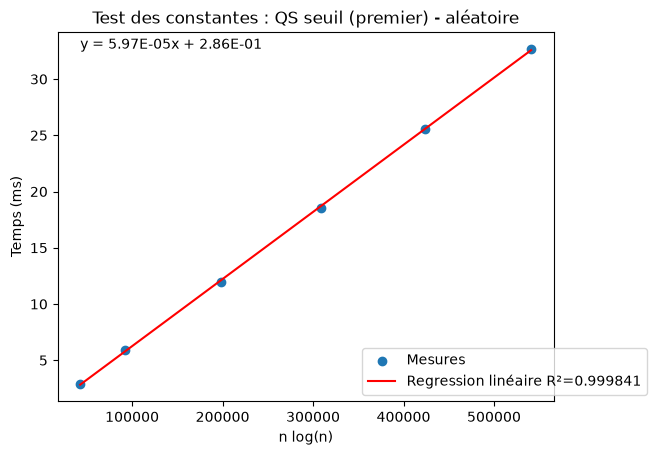

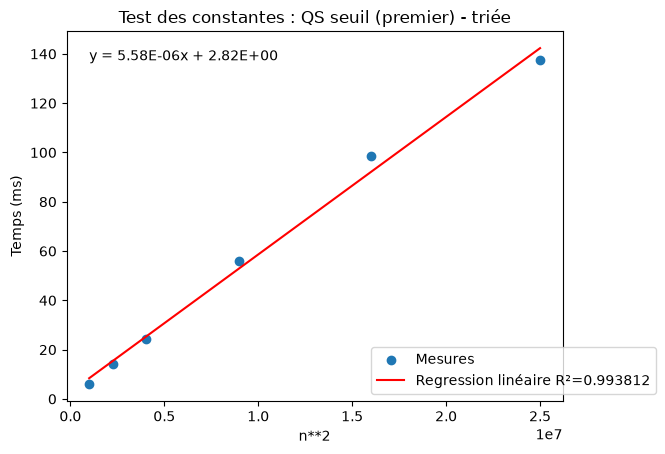

In [52]:
# TODO Test des constantes de quick_sort_threshold_first
test_de_constantes(
    data={m.size * math.log(m.size): m.mean for m in mesures_seuil_first_random},
    x_label="n log(n)",
    y_label="Temps (ms)",
    title="Test des constantes : QS seuil (premier) - aléatoire"
)

test_de_constantes(
    data={m.size**2: m.mean for m in mesures_seuil_first_sorted},
    x_label="n**2",
    y_label="Temps (ms)",
    title="Test des constantes : QS seuil (premier) - triée"
)

<u>**Question 4.b):**</u> Analysez le graphe obtenu pour le test des constantes.

Réponse :

Le test des constantes montre une bonne régression linéaire, R^2 est très proche de 1 pour T(n) en fonction de n log n (les listes aléatoires), et en fonction de n^2 (les listes triées). Cela confirme nos modèles asymptotiques et permet d'estimer la constante multiplicative du temps d'exécution.

<u>**Question 4.c):**</u> Effectuez le test des constantes de votre algorithme en prenant un élément aléatoire comme pivot.

N'oubliez pas d'analyser les exemplaires aléatoires et les exemplaires triés séparément dans des graphiques différents.

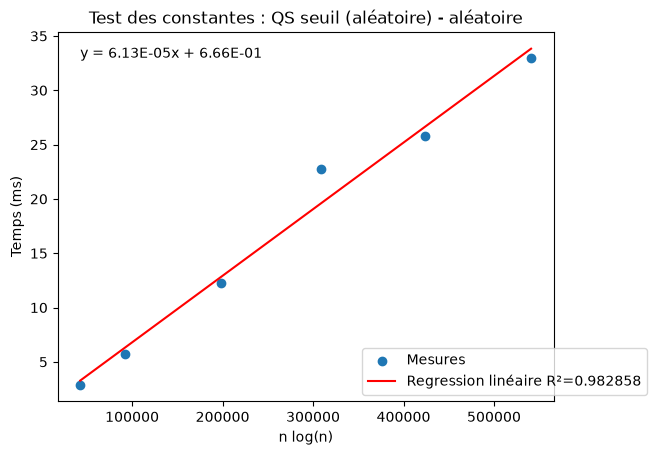

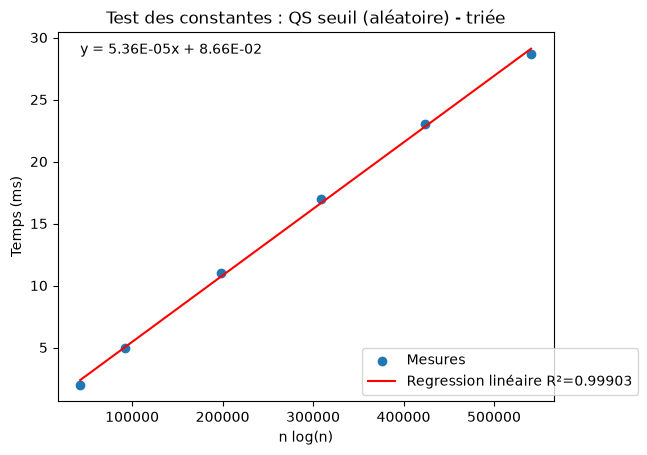

In [53]:
# TODO Test des constantes de quick_sort_threshold_random
test_de_constantes(
    data={m.size * math.log(m.size): m.mean for m in mesures_seuil_random_random},
    x_label="n log(n)",
    y_label="Temps (ms)",
    title="Test des constantes : QS seuil (aléatoire) - aléatoire"
)

test_de_constantes(
    data={m.size * math.log(m.size): m.mean for m in mesures_seuil_random_sorted},
    x_label="n log(n)",
    y_label="Temps (ms)",
    title="Test des constantes : QS seuil (aléatoire) - triée"
)

<u>**Question 4.d):**</u> Analysez le graphe obtenu pour le test des constantes.

Réponse : 
La régression est linéaire par rapport à n log n pour les distributions aléatoires et triées L'alignement des points confirme la stabilité du O(n log n) avec un pivot aléatoire.

<u>**Question 5):**</u> Commentez l'impact du seuil de récursivité. Que représente-t-il pour l'algorithme diviser pour régner et l'algorithme naïf ?

Réponse :

Le seuil de récursivité agit comme le point de bascule entre les deux approches de tri.

Diviser pour régner : Il permet d'éviter les nombreux appels récursifs en bas de l'arbre, là où l'overhead de la récursion coûte plus cher que le tri lui-même.
Naïf : Il représente la taille limite pour laquelle sa faible constante multiplicative compense sa mauvaise complexité asymptotique de O(n^2). En dessous de cette taille, il est plus performant.

# Conclusion (3 pts)

Résumez brièvement les principales observations issues de vos analyses et indiquez dans quelles situations chacun des algorithmes étudiés serait le plus approprié. Justifiez vos conclusions à l’aide des résultats obtenus.

Réponse :

Le tri par sélection naïf et bidirectionnel ont une complexité en O(n^2). Le bidirectionnel est plus rapide en pratique grâce à sa plus faible constante multiplicative, mais ne change pas la classe de complexité. Le quick sort classique est très performant en moyenne en O(n log n), mais il est vulnérable au pire cas O(n^2) s'il utilise le premier élément comme pivot sur des listes déjà presque triées. Heureusement, l'utilisation d'un pivot aléatoire résout ce problème de façon probabiliste et maintient un O(n log n) attendu, peu importe la distribution d'entrée. Le mélange de quick sort + selection sort sous un certain seuil offre des gains de performance marginaux mais constants en éliminant l'overhead des appels récursifs pour les petites tailles.

Le tri par sélection bidirectionnel est suffisant pour les petites listes (n < 20) et performant grâce avec sa simplicité et sa faible empreinte. Il faut utiliser le quick sort hybride avec un pivot aléatoire sur les plus grosses listes car il offre de très bonnes performances en moyenne tout en évitant les dégradations catastrophiques en O(n^2) sur des données ordonnées.

 ## Autres critères (2 pts)
 Qualité du code / 1 pt

Présentation générale / 1 pt

- Concision
- Qualité du français

Pénalité retard
- -2 pt / journée de retard, arrondi vers le haut. Les TPs ne sont plus acceptés après 3 jours.